Import packages

In [ ]:
!pip install pennylane

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.2/57.2 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 58.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 29.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 65.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 72.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 64.8 MB/s eta 0:00:00


In [ ]:
# Basic
import os
import zipfile
import shutil
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Torch
import torch
import torch.nn as nn
import torch.optim as optim

# Quantum
import pennylane as qml

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
zip_path = "/content/drive/MyDrive/Br35H2.zip"   # change if needed
extract_path = "/content/dataset"

# Remove old dataset if exists
if os.path.exists(extract_path):
    shutil.rmtree(extract_path)

os.makedirs(extract_path)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction complete.")
print("Folders inside dataset:", os.listdir(extract_path))

Extraction complete.
Folders inside dataset: ['Br35H2', '__MACOSX']


In [ ]:
base_path = "/content/dataset"

if "Br35H2" in os.listdir(base_path):
    inner = os.path.join(base_path, "Br35H2")

    for item in os.listdir(inner):
        shutil.move(os.path.join(inner, item), base_path)

    shutil.rmtree(inner)

if "__MACOSX" in os.listdir(base_path):
    shutil.rmtree(os.path.join(base_path, "__MACOSX"))

print("Final structure:", os.listdir(base_path))

Final structure: ['.DS_Store', 'no_tumor', 'tumor']


In [ ]:
import os

dataset_path = "/content/dataset"

# Remove .DS_Store
ds_store_path = os.path.join(dataset_path, ".DS_Store")

if os.path.exists(ds_store_path):
    os.remove(ds_store_path)
    print(".DS_Store removed.")
else:
    print("No .DS_Store found.")

print("Final clean structure:", os.listdir(dataset_path))

.DS_Store removed.
Final clean structure: ['no_tumor', 'tumor']


In [ ]:
dataset_path = "/content/dataset"

classes = [c for c in os.listdir(dataset_path)
           if os.path.isdir(os.path.join(dataset_path, c))]

print("Number of Classes:", len(classes))
print("Classes:", classes)

total_images = 0

for cls in classes:
    count = len(os.listdir(os.path.join(dataset_path, cls)))
    total_images += count
    print(f"{cls}: {count} images")

print("Total Images:", total_images)

Number of Classes: 2
Classes: ['no_tumor', 'tumor']
no_tumor: 1500 images
tumor: 1500 images
Total Images: 3000


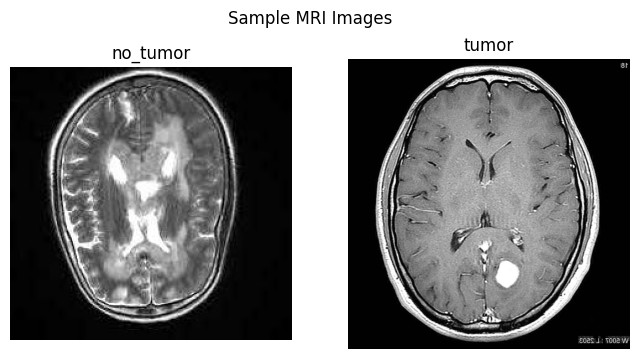

In [ ]:
plt.figure(figsize=(8,4))

for i, cls in enumerate(classes):
    folder = os.path.join(dataset_path, cls)
    img_name = random.choice(os.listdir(folder))
    img = Image.open(os.path.join(folder, img_name))

    plt.subplot(1,2,i+1)
    plt.imshow(img, cmap='gray')
    plt.title(cls)
    plt.axis('off')

plt.suptitle("Sample MRI Images")
plt.show()

In [ ]:
def load_images(path, size=(64,64)):
    X, y = [], []
    classes = ["no_tumor", "tumor"]

    for label, cls in enumerate(classes):
        folder = os.path.join(path, cls)

        for file in os.listdir(folder):
            img = Image.open(os.path.join(folder,file)).convert('L')
            img = img.resize(size)
            img = np.array(img).flatten() / 255.0  # NORMALIZATION

            X.append(img)
            y.append(label)

    return np.array(X), np.array(y)

X, y = load_images(dataset_path)

print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)

Feature matrix shape: (3000, 4096)
Label vector shape: (3000,)


In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np

# train val test = 70/15/15
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=42
)


X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

# Print dataset sizes
print("Train samples:", len(X_train))
print("Validation samples:", len(X_val))
print("Test samples:", len(X_test))

# Print class distributions
print("Train distribution:", np.bincount(y_train))
print("Validation distribution:", np.bincount(y_val))
print("Test distribution:", np.bincount(y_test))

Train samples: 2100
Validation samples: 450
Test samples: 450
Train distribution: [1050 1050]
Validation distribution: [225 225]
Test distribution: [225 225]


In [ ]:
import numpy as np

def augment_data(X, y):
    noise = np.random.normal(0, 0.03, X.shape)
    X_aug = X + noise
    X_aug = np.clip(X_aug, 0, 1)
    return np.vstack([X, X_aug]), np.hstack([y, y])

X_train_aug, y_train_aug = augment_data(X_train, y_train)

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Standard Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_aug)   # USE AUGMENTED DATA
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

#  update labels
y_train = y_train_aug

# pca
pca = PCA(n_components=150)

X_train_pca = pca.fit_transform(X_train_scaled)
X_val_pca   = pca.transform(X_val_scaled)
X_test_pca  = pca.transform(X_test_scaled)

from sklearn.preprocessing import StandardScaler

post_scaler = StandardScaler()

X_train_pca = post_scaler.fit_transform(X_train_pca)
X_val_pca   = post_scaler.transform(X_val_pca)
X_test_pca  = post_scaler.transform(X_test_pca)


import joblib
joblib.dump(post_scaler, "post_scaler.pkl")

joblib.dump(scaler, "scaler.pkl")
joblib.dump(pca, "pca.pkl")

print("Scaler and PCA saved successfully.")

print("New feature dimension:", X_train_pca.shape[1])
print("Total variance retained:", sum(pca.explained_variance_ratio_))

Scaler and PCA saved successfully.
New feature dimension: 150
Total variance retained: 0.8794255120204203


In [ ]:
import joblib

joblib.dump(scaler, "scaler.pkl")
joblib.dump(pca, "pca.pkl")

['pca.pkl']

In [ ]:
print("After PCA:")
print("Train shape:", X_train_pca.shape)
print("Validation shape:", X_val_pca.shape)
print("Test shape:", X_test_pca.shape)

After PCA:
Train shape: (4200, 150)
Validation shape: (450, 150)
Test shape: (450, 150)


In [ ]:
explained_variance = sum(pca.explained_variance_ratio_)
print(f"Total variance retained: {explained_variance:.4f}")

Total variance retained: 0.8794


In [ ]:
import torch

# Convert PCA output to tensors
X_train_t = torch.tensor(X_train_pca, dtype=torch.float32)
X_val_t   = torch.tensor(X_val_pca, dtype=torch.float32)
X_test_t  = torch.tensor(X_test_pca, dtype=torch.float32)

# Labels (important: shape [N,1])
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
y_val_t   = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)
y_test_t  = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

print("Train tensor shape:", X_train_t.shape)
print("Label tensor shape:", y_train_t.shape)

Train tensor shape: torch.Size([4200, 150])
Label tensor shape: torch.Size([4200, 1])


In [ ]:
print(type(X_train_pca))
print(type(X_train_t))

<class 'numpy.ndarray'>
<class 'torch.Tensor'>


In [ ]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset   = TensorDataset(X_val_t, y_val_t)
test_dataset  = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32)
test_loader  = DataLoader(test_dataset, batch_size=32)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 132
Validation batches: 15
Test batches: 15


In [ ]:
INPUT_DIM = X_train_pca.shape[1]
FEATURE_DIM = 8

class FCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.feature_extractor = nn.Sequential(
            nn.Linear(INPUT_DIM, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, FEATURE_DIM),
            nn.ReLU()
        )

        self.classifier = nn.Linear(FEATURE_DIM, 1)

    def forward(self, x):
        features = self.feature_extractor(x)
        return self.classifier(features)

In [ ]:
model = FCNN()

criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([1.0]))

optimizer = torch.optim.Adam(
    model.parameters(),
    lr = 5e-5,
    weight_decay=2e-3   # Slightly stronger regularization
)

In [ ]:
train_losses = []
val_losses = []
train_accs = []
val_accs = []

best_val_loss = float("inf")
patience = 5
counter = 0

def evaluate(loader):
    model.eval()
    correct = 0
    total = 0
    total_loss = 0

    with torch.no_grad():
        for xb, yb in loader:
            outputs = model(xb)
            loss = criterion(outputs, yb)
            total_loss += loss.item()

            preds = (torch.sigmoid(outputs) > 0.5).float()
            correct += (preds == yb).sum().item()
            total += yb.size(0)

    return total_loss/len(loader), correct/total


for epoch in range(30):

    model.train()
    total_train_loss = 0
    correct = 0
    total = 0

    for xb, yb in train_loader:
        optimizer.zero_grad()
        outputs = model(xb)
        loss = criterion(outputs, yb)
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

        preds = (torch.sigmoid(outputs) > 0.5).float()
        correct += (preds == yb).sum().item()
        total += yb.size(0)

    train_loss = total_train_loss / len(train_loader)
    train_acc = correct / total

    val_loss, val_acc = evaluate(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1} | "
          f"Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"Train Acc: {train_acc:.4f} | "
          f"Val Acc: {val_acc:.4f}")

    # Early stopping logic
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
        torch.save(model.state_dict(), "best_model.pth")
    else:
        counter += 1

    if counter >= patience:
        print("Early stopping triggered")
        break

Epoch 1 | Train Loss: 0.7061 | Val Loss: 0.7002 | Train Acc: 0.5000 | Val Acc: 0.5000
Epoch 2 | Train Loss: 0.7029 | Val Loss: 0.6957 | Train Acc: 0.5000 | Val Acc: 0.5000
Epoch 3 | Train Loss: 0.6974 | Val Loss: 0.6901 | Train Acc: 0.5000 | Val Acc: 0.5000
Epoch 4 | Train Loss: 0.6921 | Val Loss: 0.6847 | Train Acc: 0.5026 | Val Acc: 0.5000
Epoch 5 | Train Loss: 0.6850 | Val Loss: 0.6781 | Train Acc: 0.5081 | Val Acc: 0.5178
Epoch 6 | Train Loss: 0.6790 | Val Loss: 0.6709 | Train Acc: 0.5281 | Val Acc: 0.5511
Epoch 7 | Train Loss: 0.6708 | Val Loss: 0.6623 | Train Acc: 0.5640 | Val Acc: 0.5822
Epoch 8 | Train Loss: 0.6558 | Val Loss: 0.6469 | Train Acc: 0.6364 | Val Acc: 0.7089
Epoch 9 | Train Loss: 0.6386 | Val Loss: 0.6313 | Train Acc: 0.7031 | Val Acc: 0.7556
Epoch 10 | Train Loss: 0.6168 | Val Loss: 0.6069 | Train Acc: 0.7531 | Val Acc: 0.7911
Epoch 11 | Train Loss: 0.5883 | Val Loss: 0.5746 | Train Acc: 0.7893 | Val Acc: 0.8133
Epoch 12 | Train Loss: 0.5551 | Val Loss: 0.5402 | T

In [ ]:
model = FCNN()
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

FCNN(
  (feature_extractor): Sequential(
    (0): Linear(in_features=150, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): ReLU()
    (6): Linear(in_features=32, out_features=8, bias=True)
    (7): ReLU()
  )
  (classifier): Linear(in_features=8, out_features=1, bias=True)
)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for xb, yb in test_loader:
        outputs = model(xb)
        preds = (torch.sigmoid(outputs) > 0.5).float()

        all_preds.extend(preds.numpy())
        all_labels.extend(yb.numpy())

print("Confusion Matrix:")
print(confusion_matrix(all_labels, all_preds))

print("\nClassification Report:")
print(classification_report(all_labels, all_preds))

Confusion Matrix:
[[211  14]
 [ 18 207]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.92      0.94      0.93       225
         1.0       0.94      0.92      0.93       225

    accuracy                           0.93       450
   macro avg       0.93      0.93      0.93       450
weighted avg       0.93      0.93      0.93       450



In [ ]:
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

FCNN(
  (feature_extractor): Sequential(
    (0): Linear(in_features=150, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): ReLU()
    (6): Linear(in_features=32, out_features=8, bias=True)
    (7): ReLU()
  )
  (classifier): Linear(in_features=8, out_features=1, bias=True)
)

In [ ]:
all_preds = []
all_probs = []
all_labels = []

with torch.no_grad():
    for xb, yb in test_loader:
        outputs = model(xb)

        probs = torch.sigmoid(outputs)      # probabilities
        preds = (probs > 0.5).float()       # binary predictions

        all_probs.extend(probs.numpy())
        all_preds.extend(preds.numpy())
        all_labels.extend(yb.numpy())

In [ ]:
from sklearn.metrics import accuracy_score

test_accuracy = accuracy_score(all_labels, all_preds)
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Accuracy: 0.9289


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

print("Confusion Matrix:")
print(confusion_matrix(all_labels, all_preds))

print("\nClassification Report:")
print(classification_report(all_labels, all_preds))

Confusion Matrix:
[[211  14]
 [ 18 207]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.92      0.94      0.93       225
         1.0       0.94      0.92      0.93       225

    accuracy                           0.93       450
   macro avg       0.93      0.93      0.93       450
weighted avg       0.93      0.93      0.93       450



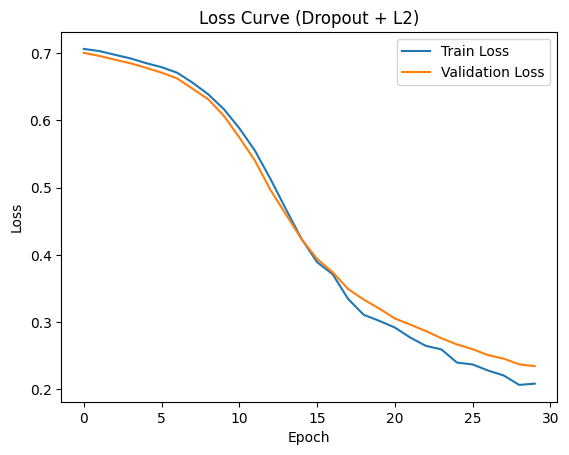

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve (Dropout + L2)")
plt.show()

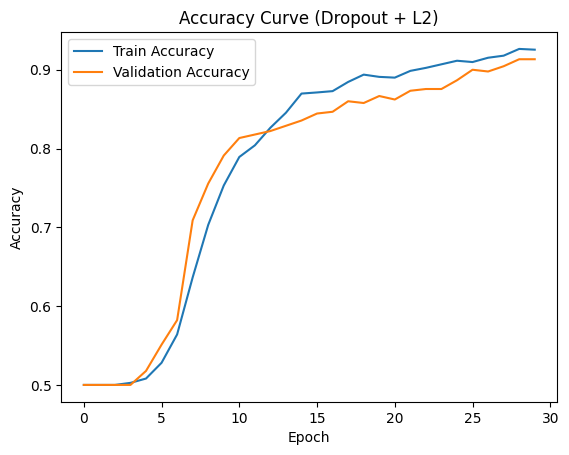

In [ ]:
plt.figure()
plt.plot(train_accs, label="Train Accuracy")
plt.plot(val_accs, label="Validation Accuracy")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve (Dropout + L2)")
plt.show()

In [ ]:
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

FCNN(
  (feature_extractor): Sequential(
    (0): Linear(in_features=150, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): ReLU()
    (6): Linear(in_features=32, out_features=8, bias=True)
    (7): ReLU()
  )
  (classifier): Linear(in_features=8, out_features=1, bias=True)
)

In [ ]:
def get_accuracy(loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for xb, yb in loader:
            outputs = model(xb)
            preds = (torch.sigmoid(outputs) > 0.5).float()
            correct += (preds == yb).sum().item()
            total += yb.size(0)

    return correct / total

In [ ]:
train_acc = get_accuracy(train_loader)
val_acc   = get_accuracy(val_loader)
test_acc  = get_accuracy(test_loader)

print(f"Final Train Accuracy: {train_acc:.4f}")
print(f"Final Validation Accuracy: {val_acc:.4f}")
print(f"Final Test Accuracy: {test_acc:.4f}")

Final Train Accuracy: 0.9652
Final Validation Accuracy: 0.9133
Final Test Accuracy: 0.9289


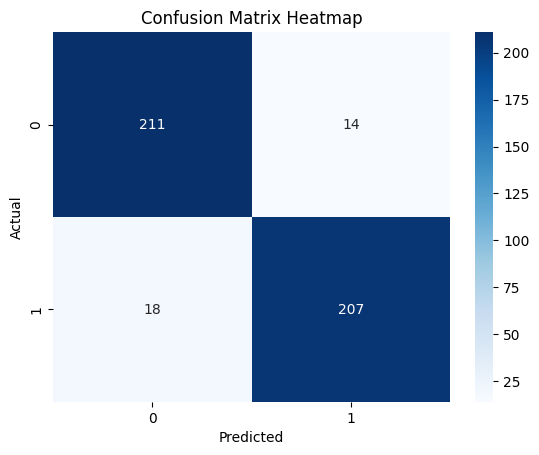

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(all_labels, all_preds)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix Heatmap")
plt.show()

In [ ]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

print(f"AUC Score: {roc_auc:.4f}")

AUC Score: 0.9722


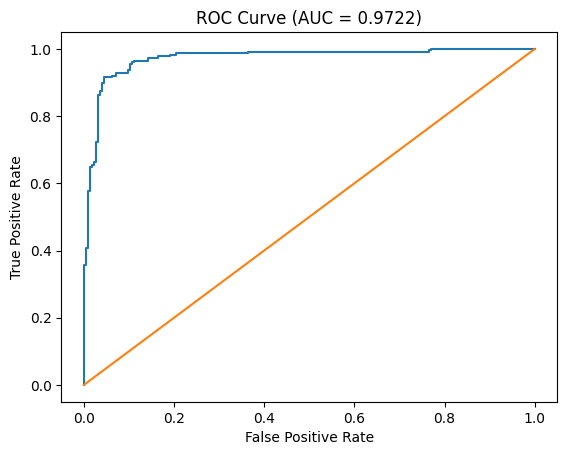

In [ ]:
from sklearn.metrics import roc_curve, auc

model.eval()
all_probs = []
all_labels = []

with torch.no_grad():
    for xb, yb in test_loader:
        outputs = model(xb)
        probs = torch.sigmoid(outputs)
        all_probs.extend(probs.numpy())
        all_labels.extend(yb.numpy())

fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve (AUC = {roc_auc:.4f})")
plt.show()

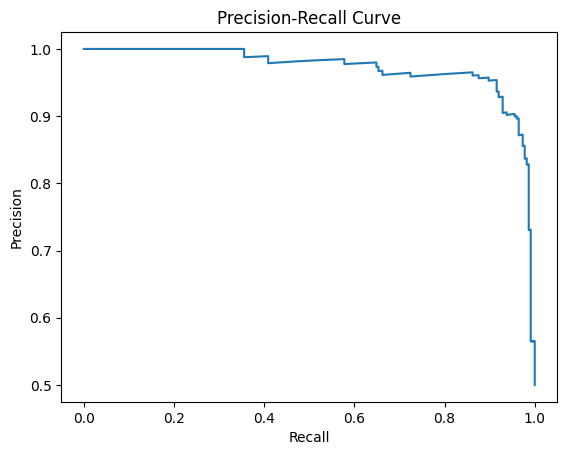

In [ ]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(all_labels, all_probs)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

In [ ]:
# Extract features from test set
model.eval()
features_list = []
labels_list = []

with torch.no_grad():
    for xb, yb in test_loader:
        features = model.feature_extractor(xb)
        features_list.extend(features.numpy())
        labels_list.extend(yb.numpy())

features_array = np.array(features_list)
labels_array = np.array(labels_list)

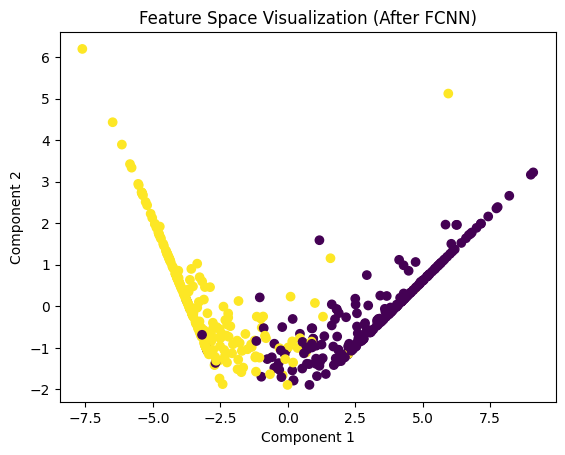

In [ ]:
from sklearn.decomposition import PCA

pca_vis = PCA(n_components=2)
features_2d = pca_vis.fit_transform(features_array)

plt.figure()
plt.scatter(features_2d[:,0], features_2d[:,1], c=labels_array)
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.title("Feature Space Visualization (After FCNN)")
plt.show()

Quantum Machine Learning

In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_curve, auc, precision_recall_curve,
)
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import pennylane as qml
print("All imports successful")
print(f"PyTorch version: {torch.__version__}")
print(f"PennyLane version: {qml.__version__}")
print(f"Device: {'cuda' if torch.cuda.is_available() else 'cpu'}")

All imports successful
PyTorch version: 2.10.0+cu128
PennyLane version: 0.44.0
Device: cuda


In [ ]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
INPUT_DIM   = 150       # PCA output dimension
FEATURE_DIM = 8         # FCNN feature extractor output / number of qubits
N_QUBITS    = FEATURE_DIM
N_LAYERS    = 6         # Number of variational layers in the VQC
BATCH_SIZE  = 32
LR          = 0.005     # Learning rate for VQC parameters
EPOCHS      = 50
PATIENCE    = 10
DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATASET_PATH     = "/content/dataset"       # Path to dataset
PRETRAINED_PATH  = "best_model.pth"         # Pretrained FCNN weights
BEST_VQC_PATH    = "best_vqc_model.pth"     # Where to save best VQC model
print("Configuration set")
print(f"  Qubits:           {N_QUBITS}")
print(f"  VQC layers:       {N_LAYERS}")
print(f"  Batch size:       {BATCH_SIZE}")
print(f"  Learning rate:    {LR}")
print(f"  Max epochs:       {EPOCHS}")
print(f"  Early stopping:   patience={PATIENCE}")

Configuration set
  Qubits:           8
  VQC layers:       6
  Batch size:       32
  Learning rate:    0.005
  Max epochs:       50
  Early stopping:   patience=10


In [ ]:
def load_images(path, size=(64, 64)):
    X, y = [], []
    classes = ["no_tumor", "tumor"]
    for label, cls in enumerate(classes):
        folder = os.path.join(path, cls)
        for file in os.listdir(folder):
            img = Image.open(os.path.join(folder, file)).convert("L")
            img = img.resize(size)
            img = np.array(img).flatten() / 255.0
            X.append(img)
            y.append(label)
    return np.array(X), np.array(y)
def augment_data(X, y):
    noise = np.random.normal(0, 0.03, X.shape)
    X_aug = np.clip(X + noise, 0, 1)
    return np.vstack([X, X_aug]), np.hstack([y, y])
X, y = load_images(DATASET_PATH)
print(f"Total images loaded: {len(X)}")
print(f"Feature matrix shape: {X.shape}")
print(f"Classes: no_tumor={np.sum(y==0)}, tumor={np.sum(y==1)}")

Total images loaded: 3000
Feature matrix shape: (3000, 4096)
Classes: no_tumor=1500, tumor=1500


In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)
print(f"Train samples: {len(X_train)}")
print(f"Val samples:   {len(X_val)}")
print(f"Test samples:  {len(X_test)}")
print(f"Train distribution: {np.bincount(y_train)}")
print(f"Val distribution:   {np.bincount(y_val)}")
print(f"Test distribution:  {np.bincount(y_test)}")

Train samples: 2100
Val samples:   450
Test samples:  450
Train distribution: [1050 1050]
Val distribution:   [225 225]
Test distribution:  [225 225]


In [ ]:
# Augment training data
X_train_aug, y_train_aug = augment_data(X_train, y_train)
print(f"After augmentation: {len(X_train_aug)} train samples")
# Standard scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_aug)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)
# PCA
pca = PCA(n_components=INPUT_DIM)
X_train_pca = pca.fit_transform(X_train_scaled)
X_val_pca   = pca.transform(X_val_scaled)
X_test_pca  = pca.transform(X_test_scaled)
# Post-PCA scaling
post_scaler = StandardScaler()
X_train_pca = post_scaler.fit_transform(X_train_pca)
X_val_pca   = post_scaler.transform(X_val_pca)
X_test_pca  = post_scaler.transform(X_test_pca)
y_train = y_train_aug
print(f"PCA components: {INPUT_DIM}")
print(f"Variance retained: {sum(pca.explained_variance_ratio_):.4f}")
print(f"Train PCA shape: {X_train_pca.shape}")
print(f"Train PCA mean: {X_train_pca.mean():.6f}, std: {X_train_pca.std():.6f}")

After augmentation: 4200 train samples
PCA components: 150
Variance retained: 0.8794
Train PCA shape: (4200, 150)
Train PCA mean: 0.000000, std: 1.000000


In [ ]:
X_train_t = torch.tensor(X_train_pca, dtype=torch.float32)
X_val_t   = torch.tensor(X_val_pca,   dtype=torch.float32)
X_test_t  = torch.tensor(X_test_pca,  dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
y_val_t   = torch.tensor(y_val,   dtype=torch.float32).unsqueeze(1)
y_test_t  = torch.tensor(y_test,  dtype=torch.float32).unsqueeze(1)
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val_t, y_val_t),     batch_size=BATCH_SIZE)
test_loader  = DataLoader(TensorDataset(X_test_t, y_test_t),   batch_size=BATCH_SIZE)
print(f"Train tensor: {X_train_t.shape}, Label tensor: {y_train_t.shape}")
print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")
print(f"Test batches:  {len(test_loader)}")

Train tensor: torch.Size([4200, 150]), Label tensor: torch.Size([4200, 1])
Train batches: 132
Val batches:   15
Test batches:  15


In [ ]:
class FCNN(nn.Module):
    """Original FCNN architecture — needed to load pretrained weights."""
    def __init__(self):
        super().__init__()
        self.feature_extractor = nn.Sequential(
            nn.Linear(INPUT_DIM, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, FEATURE_DIM),
            nn.ReLU(),
        )
        self.classifier = nn.Linear(FEATURE_DIM, 1)
    def forward(self, x):
        features = self.feature_extractor(x)
        return self.classifier(features)
fcnn = FCNN()
fcnn.load_state_dict(torch.load(PRETRAINED_PATH, map_location=DEVICE))
fcnn.eval()
print("Pretrained FCNN loaded ")
print(fcnn)

Pretrained FCNN loaded 
FCNN(
  (feature_extractor): Sequential(
    (0): Linear(in_features=150, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): ReLU()
    (6): Linear(in_features=32, out_features=8, bias=True)
    (7): ReLU()
  )
  (classifier): Linear(in_features=8, out_features=1, bias=True)
)


In [ ]:
dev = qml.device("default.qubit", wires=N_QUBITS)
@qml.qnode(dev, interface="torch", diff_method="backprop")
def quantum_circuit(inputs, weights):
    """
    VQC for binary classification.
      inputs  : (8,) feature vector from FCNN
      weights : (6, 8, 3) trainable rotation angles
    """
    # Encode classical features as rotation angles on qubits
    qml.AngleEmbedding(inputs, wires=range(N_QUBITS))
    # Variational layers: rotations + CNOT entanglement
    qml.StronglyEntanglingLayers(weights, wires=range(N_QUBITS))
    # Measure qubit 0 - output in [-1, 1]
    return qml.expval(qml.PauliZ(0))
print("Quantum circuit defined ")
print(f"  Qubits: {N_QUBITS}")
print(f"  Variational layers: {N_LAYERS}")
print(f"  Trainable params per layer: {N_QUBITS * 3} = {N_QUBITS}×3 rotations")
print(f"  Total VQC params: {N_LAYERS * N_QUBITS * 3}")
# Draw the circuit with dummy inputs
print("\nCircuit diagram:")
dummy_inputs = torch.randn(N_QUBITS)
dummy_weights = torch.randn(N_LAYERS, N_QUBITS, 3)
print(qml.draw(quantum_circuit)(dummy_inputs, dummy_weights))

Quantum circuit defined ✓
  Qubits: 8
  Variational layers: 6
  Trainable params per layer: 24 = 8×3 rotations
  Total VQC params: 144

Circuit diagram:
0: ─╭AngleEmbedding(M0)─╭StronglyEntanglingLayers(M1)─┤  <Z>
1: ─├AngleEmbedding(M0)─├StronglyEntanglingLayers(M1)─┤     
2: ─├AngleEmbedding(M0)─├StronglyEntanglingLayers(M1)─┤     
3: ─├AngleEmbedding(M0)─├StronglyEntanglingLayers(M1)─┤     
4: ─├AngleEmbedding(M0)─├StronglyEntanglingLayers(M1)─┤     
5: ─├AngleEmbedding(M0)─├StronglyEntanglingLayers(M1)─┤     
6: ─├AngleEmbedding(M0)─├StronglyEntanglingLayers(M1)─┤     
7: ─╰AngleEmbedding(M0)─╰StronglyEntanglingLayers(M1)─┤     

M0 = 
tensor([-0.1510,  1.7136,  0.4122,  0.1126, -1.6308, -0.1345, -0.8303, -0.8380])
M1 = 
tensor([[[ 2.1210,  0.4030,  0.1268],
         [ 0.2645,  0.7157, -0.8141],
         [-0.0984, -1.6291, -0.2065],
         [-1.5633, -0.9192, -1.3441],
         [ 2.0453,  1.1216, -0.4548],
         [-1.6779, -0.0150, -0.2243],
         [-0.0768, -1.5765,  0.3468],

/tmp/ipykernel_917/2114803803.py:4: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


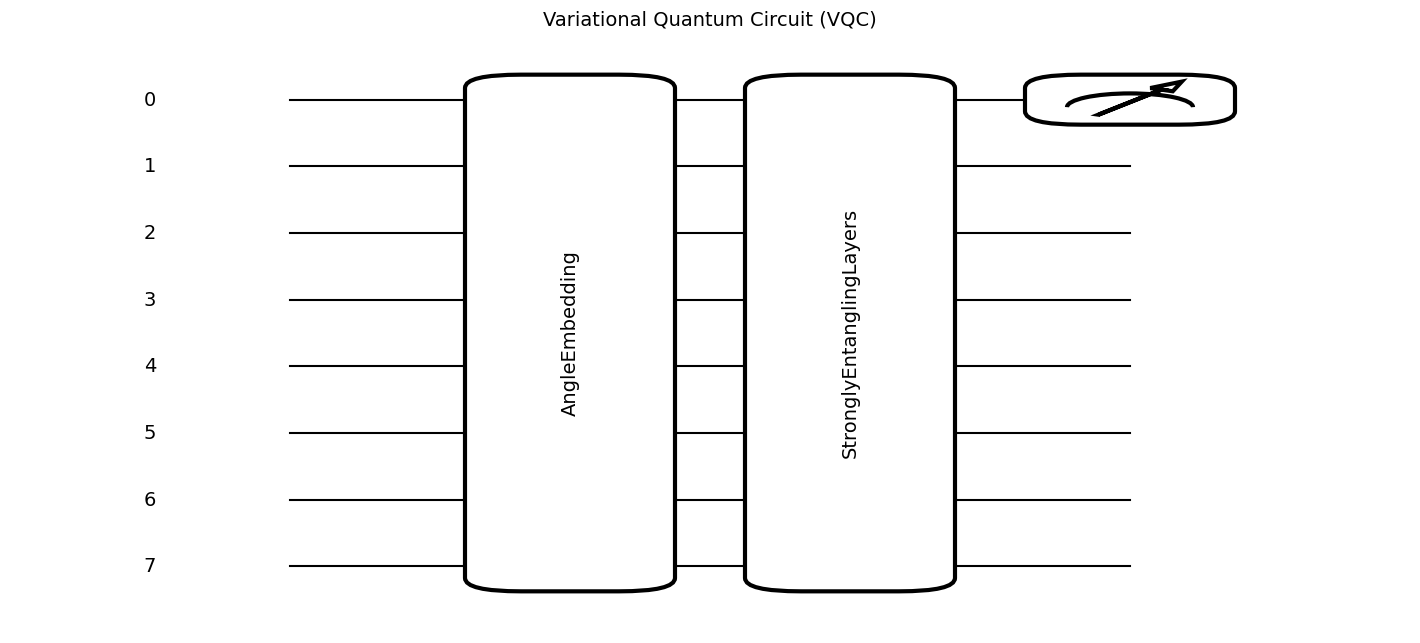

Saved - vqc_circuit_diagram.png


In [ ]:
fig, ax = qml.draw_mpl(quantum_circuit)(dummy_inputs, dummy_weights)
fig.set_size_inches(14, 6)
ax.set_title("Variational Quantum Circuit (VQC)", fontsize=14)
plt.tight_layout()
plt.savefig("vqc_circuit_diagram.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved - vqc_circuit_diagram.png")

/tmp/ipykernel_917/3704323341.py:4: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


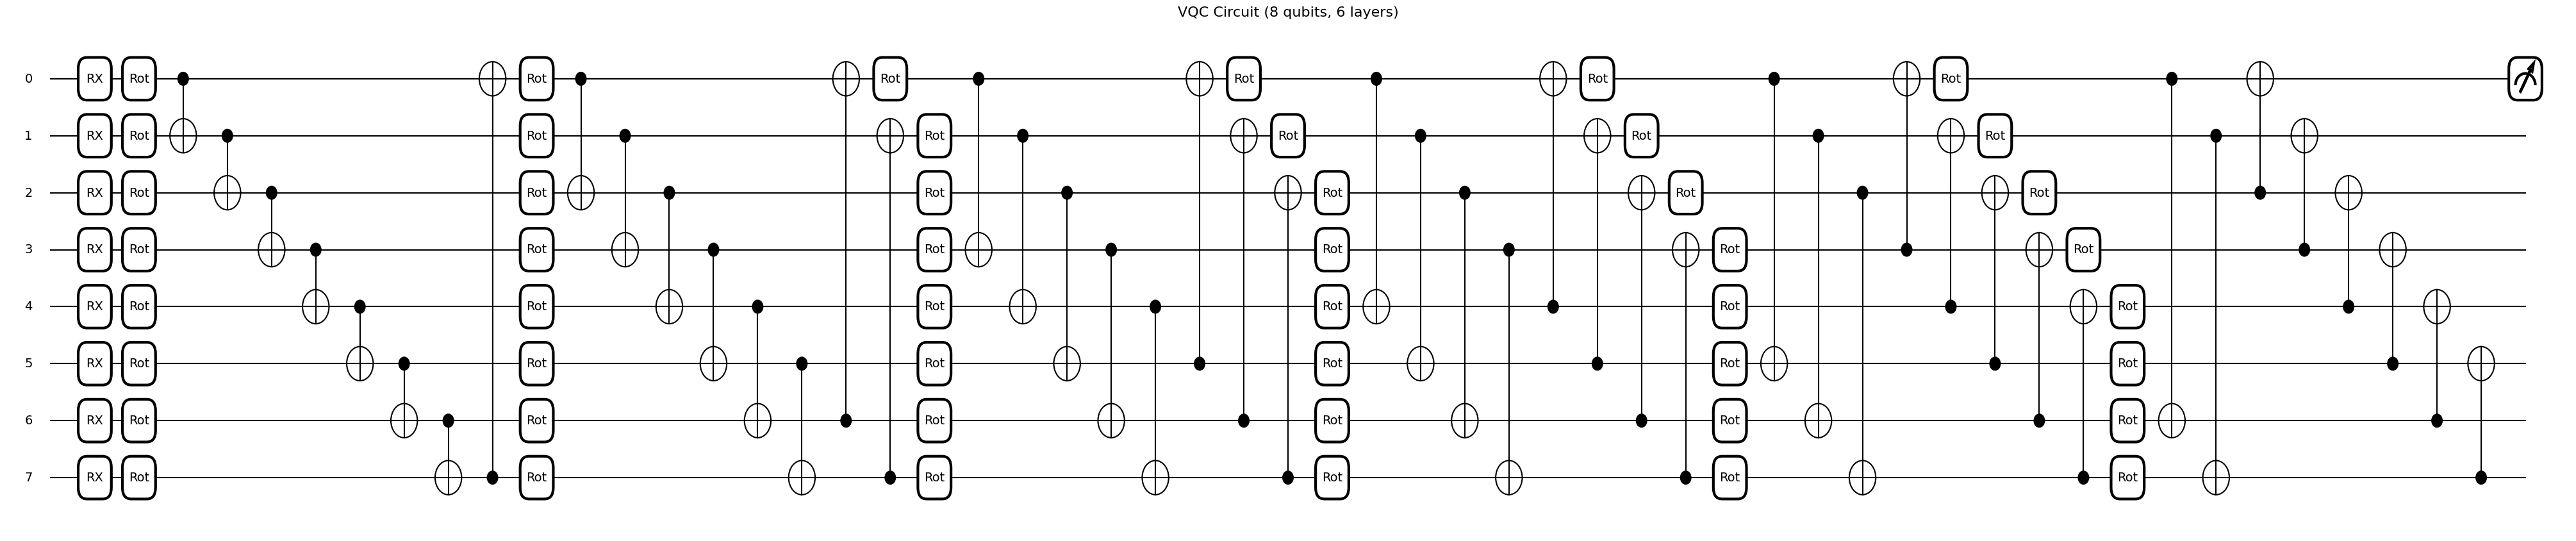

Saved - vqc_circuit_full_expanded.png


In [ ]:
fig3, ax3 = qml.draw_mpl(quantum_circuit, level="device")(dummy_inputs, dummy_weights)
fig3.set_size_inches(40, 8)
ax3.set_title("VQC Circuit (8 qubits, 6 layers)", fontsize=16)
plt.tight_layout()
plt.savefig("vqc_circuit_full_expanded.png", dpi=100, bbox_inches="tight")
plt.show()
print("Saved - vqc_circuit_full_expanded.png")

/tmp/ipykernel_917/605272023.py:11: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


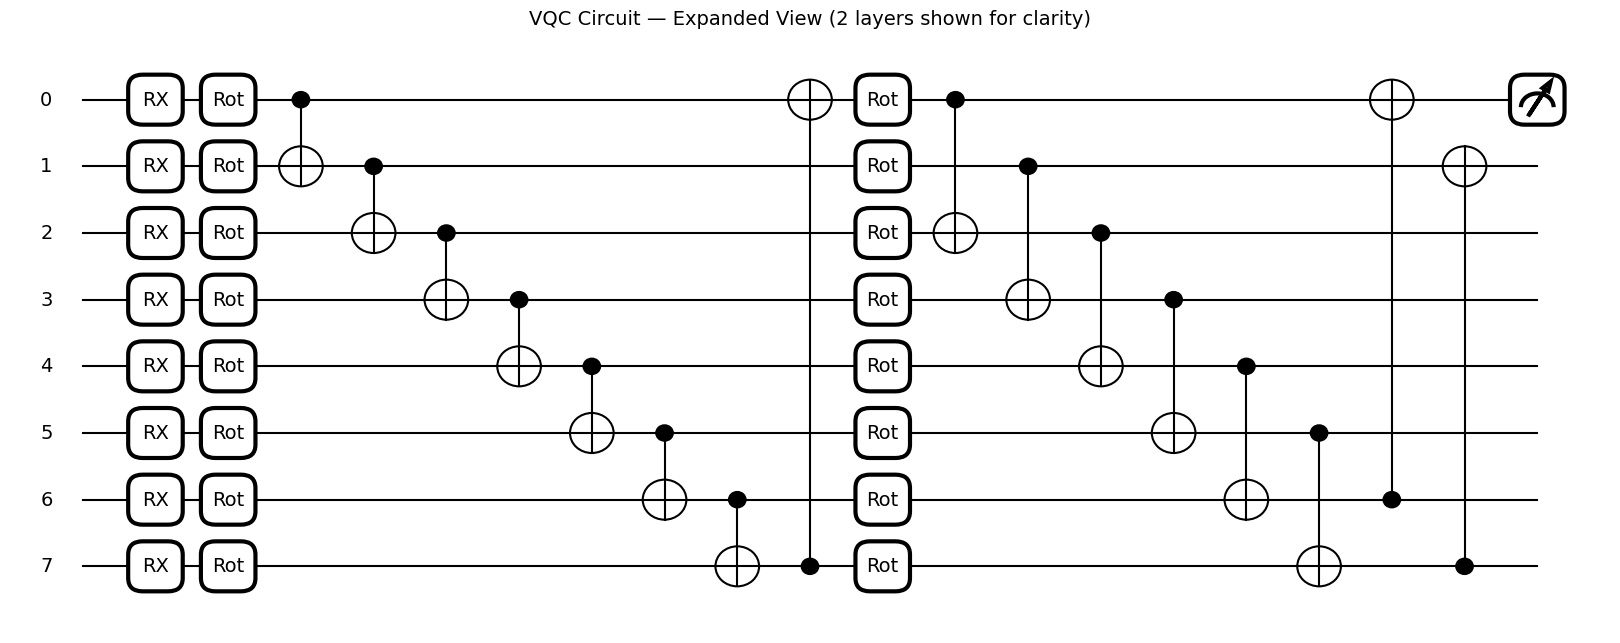

Saved - vqc_circuit_expanded.png


In [ ]:
dev_small = qml.device("default.qubit", wires=N_QUBITS)
@qml.qnode(dev_small, interface="torch")
def small_circuit(inputs, weights):
    qml.AngleEmbedding(inputs, wires=range(N_QUBITS))
    qml.StronglyEntanglingLayers(weights, wires=range(N_QUBITS))
    return qml.expval(qml.PauliZ(0))
small_weights = torch.randn(2, N_QUBITS, 3)  # only 2 layers
fig2, ax2 = qml.draw_mpl(small_circuit, level="device")(dummy_inputs, small_weights)
fig2.set_size_inches(16, 6)
ax2.set_title("VQC Circuit — Expanded View (2 layers shown for clarity)", fontsize=14)
plt.tight_layout()
plt.savefig("vqc_circuit_expanded.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved - vqc_circuit_expanded.png")

In [ ]:
from google.colab import files
files.download("vqc_circuit_diagram.png")
files.download("vqc_circuit_full_expanded.png")
files.download("vqc_circuit_expanded.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
files.download("vqc_circuit_diagram.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
files.download("vqc_circuit_full_expanded.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
class FCNN_VQC(nn.Module):
    """
    Hybrid model:
      FCNN feature_extractor - adapter - VQC classifier
    The adapter (Linear + Tanh * π) maps unbounded ReLU outputs
    to [-π, π], which is the ideal range for AngleEmbedding.
    """
    def __init__(self, pretrained_fcnn):
        super().__init__()
        # Reuse feature extractor (fine-tuned with a small lr)
        self.feature_extractor = pretrained_fcnn.feature_extractor
        # Adapter: maps ReLU outputs to [-π, π] for angle encoding
        self.adapter = nn.Sequential(
            nn.Linear(FEATURE_DIM, FEATURE_DIM),
            nn.Tanh(),                            # output in [-1, 1]
        )
        # VQC as classifier (replaces nn.Linear(8, 1))
        weight_shapes = {"weights": (N_LAYERS, N_QUBITS, 3)}
        self.vqc = qml.qnn.TorchLayer(quantum_circuit, weight_shapes)
    def forward(self, x):
        # Extract features
        features = self.feature_extractor(x)
        # Adapter: scale to [-π, π] for angle embedding
        features = self.adapter(features) * np.pi
        # VQC output in [-1, 1]
        out = self.vqc(features)
        # Remap to [0, 1] for BCELoss
        out = (out + 1.0) / 2.0
        return out.unsqueeze(1)   # shape: (batch, 1)
model = FCNN_VQC(fcnn)
model.to(DEVICE)
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
n_frozen    = sum(p.numel() for p in model.parameters() if not p.requires_grad)
print("Hybrid FCNN-VQC model built ")
print(model)
print(f"\n  Trainable params (all):  {n_trainable}")
print(f"  Frozen params:           {n_frozen}")
print(f"  Total params:            {n_trainable + n_frozen}")

Hybrid FCNN-VQC model built 
FCNN_VQC(
  (feature_extractor): Sequential(
    (0): Linear(in_features=150, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): ReLU()
    (6): Linear(in_features=32, out_features=8, bias=True)
    (7): ReLU()
  )
  (adapter): Sequential(
    (0): Linear(in_features=8, out_features=8, bias=True)
    (1): Tanh()
  )
  (vqc): <Quantum Torch Layer: func=quantum_circuit>
)

  Trainable params (all):  12352
  Frozen params:           0
  Total params:            12352


In [ ]:
print(f"Layers = {N_LAYERS}")
print(f"Qubits = {N_QUBITS}")


print("\nGate counts:")
print(f"  Rx (encoding):     {N_QUBITS}")
print(f"  Rot (variational): {N_LAYERS * N_QUBITS}")
print(f"  CNOT (entangle):   {N_LAYERS * N_QUBITS}")
print(f"\n  Total gates: {N_QUBITS + (2 * (N_LAYERS * N_QUBITS))}")
print(f"  Gates per layer: {N_QUBITS} Rot + {N_QUBITS} CNOT = {2 * N_QUBITS}")

print("\n\nLayer breakdown:")
print(f"  Encoding layers:     1 (AngleEmbedding)")
print(f"  Variational layers:  {N_LAYERS} (StronglyEntanglingLayers)")
print(f"  Measurement:         1 (PauliZ on qubit 0)")
print(f"  Total layers:        {1 + N_LAYERS + 1}")

print(f"\n\nPer variational layer:")
print(f"  Rot gates:  {N_QUBITS} (1 per qubit × 3 rotations each)")
print(f"  CNOT gates: {N_QUBITS} (circular entanglement)")
print(f"  Params:     {N_QUBITS * 3} ({N_QUBITS} qubits × 3 angles)")


Layers = 6
Qubits = 8

Gate counts:
  Rx (encoding):     8
  Rot (variational): 48
  CNOT (entangle):   48

  Total gates: 104
  Gates per layer: 8 Rot + 8 CNOT = 16


Layer breakdown:
  Encoding layers:     1 (AngleEmbedding)
  Variational layers:  6 (StronglyEntanglingLayers)
  Measurement:         1 (PauliZ on qubit 0)
  Total layers:        8


Per variational layer:
  Rot gates:  8 (1 per qubit × 3 rotations each)
  CNOT gates: 8 (circular entanglement)
  Params:     24 (8 qubits × 3 angles)


In [ ]:
#print hybrid model architecture
print("=" * 60)
print("  FCNN-VQC Hybrid Model Architecture")
print("=" * 60)

print("\n📋 Model Structure:")
print(model)

print("\n" + "=" * 60)
print("  Parameter Summary")
print("=" * 60)

print(f"\n{'Component':<30} {'Params':>10} {'Trainable':>10}")
print("-" * 52)

# Feature extractor
fe_params = sum(p.numel() for p in model.feature_extractor.parameters())
fe_train  = sum(p.numel() for p in model.feature_extractor.parameters() if p.requires_grad)
print(f"{'FCNN Feature Extractor':<30} {fe_params:>10,} {fe_train:>10,}")

# Adapter
ad_params = sum(p.numel() for p in model.adapter.parameters())
ad_train  = sum(p.numel() for p in model.adapter.parameters() if p.requires_grad)
print(f"{'Adapter (Linear+Tanh)':<30} {ad_params:>10,} {ad_train:>10,}")

# VQC
vqc_params = sum(p.numel() for p in model.vqc.parameters())
vqc_train  = sum(p.numel() for p in model.vqc.parameters() if p.requires_grad)
print(f"{'VQC (Quantum Circuit)':<30} {vqc_params:>10,} {vqc_train:>10,}")

print("-" * 52)
total = fe_params + ad_params + vqc_params
total_train = fe_train + ad_train + vqc_train
print(f"{'TOTAL':<30} {total:>10,} {total_train:>10,}")

print(f"\n Quantum Circuit Details:")
print(f"  Qubits:              {N_QUBITS}")
print(f"  Variational layers:  {N_LAYERS}")
print(f"  Gates per layer:     8 Rot + 8 CNOT = 16")
print(f"  Total gates:         8 Rx + {N_LAYERS}×16 = {8 + N_LAYERS*16}")
print(f"  Trainable params:    {N_LAYERS} × {N_QUBITS} × 3 = {N_LAYERS * N_QUBITS * 3}")


  FCNN-VQC Hybrid Model Architecture

📋 Model Structure:
FCNN_VQC(
  (feature_extractor): Sequential(
    (0): Linear(in_features=150, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): ReLU()
    (6): Linear(in_features=32, out_features=8, bias=True)
    (7): ReLU()
  )
  (adapter): Sequential(
    (0): Linear(in_features=8, out_features=8, bias=True)
    (1): Tanh()
  )
  (vqc): <Quantum Torch Layer: func=quantum_circuit>
)

  Parameter Summary

Component                          Params  Trainable
----------------------------------------------------
FCNN Feature Extractor             12,136     12,136
Adapter (Linear+Tanh)                  72         72
VQC (Quantum Circuit)                 144        144
----------------------------------------------------
TOTAL                              12,35

In [ ]:
criterion = nn.BCELoss()
# Differential learning rates:
# FCNN feature extractor: small lr (fine-tune gently)
# Adapter + VQC : larger lr (needs to learn from scratch)
optimizer = optim.Adam([
    {"params": model.feature_extractor.parameters(), "lr": 5e-5},
    {"params": model.adapter.parameters(),           "lr": 0.01,  "weight_decay": 1e-4},
    {"params": model.vqc.parameters(),               "lr": 0.01,  "weight_decay": 1e-4},
])
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
train_losses, val_losses = [], []
train_accs,   val_accs   = [], []
best_val_loss = float("inf")
counter = 0
print("Starting training...\n")
for epoch in range(1, EPOCHS + 1):
    #  Train
    model.train()
    running_loss = 0.0
    correct = 0
    total   = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(xb)
        loss = criterion(outputs, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        preds = (outputs > 0.5).float()
        correct += (preds == yb).sum().item()
        total   += yb.size(0)
    train_loss = running_loss / len(train_loader)
    train_acc  = correct / total
    #  Validate
    model.eval()
    val_running_loss = 0.0
    val_correct = 0
    val_total   = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            outputs = model(xb)
            loss = criterion(outputs, yb)
            val_running_loss += loss.item()
            preds = (outputs > 0.5).float()
            val_correct += (preds == yb).sum().item()
            val_total   += yb.size(0)
    val_loss = val_running_loss / len(val_loader)
    val_acc  = val_correct / val_total
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    print(
        f"Epoch {epoch:2d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}"
    )
    #  Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
        torch.save(model.state_dict(), BEST_VQC_PATH)
        print(f"    Best model saved (val_loss={val_loss:.4f})")
    else:
        counter += 1
        print(f"    No improvement ({counter}/{PATIENCE})")
    scheduler.step()
    if counter >= PATIENCE:
        print("\nEarly stopping triggered!")
        break
print(f"\nTraining complete. Best val loss: {best_val_loss:.4f}")

Starting training...

Epoch  1/50 | Train Loss: 0.4899 | Val Loss: 0.5011 | Train Acc: 0.8281 | Val Acc: 0.7933
    Best model saved (val_loss=0.5011)
Epoch  2/50 | Train Loss: 0.4182 | Val Loss: 0.4585 | Train Acc: 0.8533 | Val Acc: 0.8111
    Best model saved (val_loss=0.4585)
Epoch  3/50 | Train Loss: 0.3754 | Val Loss: 0.4408 | Train Acc: 0.8743 | Val Acc: 0.8378
    Best model saved (val_loss=0.4408)
Epoch  4/50 | Train Loss: 0.3485 | Val Loss: 0.3987 | Train Acc: 0.8876 | Val Acc: 0.8378
    Best model saved (val_loss=0.3987)
Epoch  5/50 | Train Loss: 0.3162 | Val Loss: 0.3739 | Train Acc: 0.9007 | Val Acc: 0.8578
    Best model saved (val_loss=0.3739)
Epoch  6/50 | Train Loss: 0.2912 | Val Loss: 0.3453 | Train Acc: 0.9055 | Val Acc: 0.8733
    Best model saved (val_loss=0.3453)
Epoch  7/50 | Train Loss: 0.2543 | Val Loss: 0.3230 | Train Acc: 0.9207 | Val Acc: 0.8756
    Best model saved (val_loss=0.3230)
Epoch  8/50 | Train Loss: 0.2469 | Val Loss: 0.3163 | Train Acc: 0.9250 | V

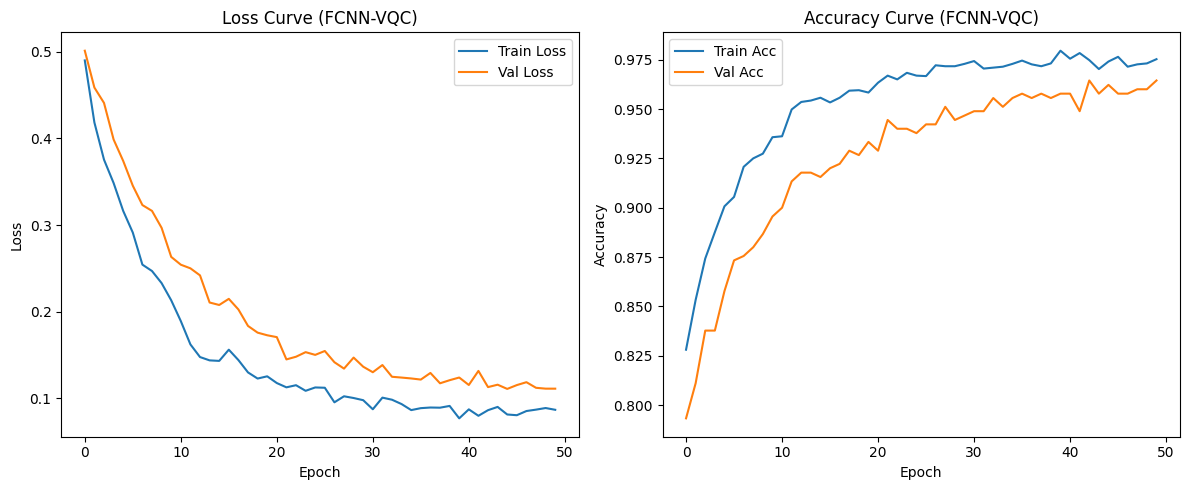

Training curves saved → vqc_training_results.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(train_losses, label="Train Loss")
axes[0].plot(val_losses,   label="Val Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss Curve (FCNN-VQC)")
axes[0].legend()
axes[1].plot(train_accs, label="Train Acc")
axes[1].plot(val_accs,   label="Val Acc")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy Curve (FCNN-VQC)")
axes[1].legend()
plt.tight_layout()
plt.savefig("vqc_training_results.png", dpi=150)
plt.show()
print("Training curves saved → vqc_training_results.png")

In [ ]:
model.load_state_dict(torch.load(BEST_VQC_PATH, map_location=DEVICE))
model.eval()
print("Best VQC model loaded")

Best VQC model loaded


In [ ]:
all_preds  = []
all_probs  = []
all_labels = []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(DEVICE)
        outputs = model(xb)
        probs   = outputs.cpu()
        preds   = (probs > 0.5).float()
        all_probs.extend(probs.numpy())
        all_preds.extend(preds.numpy())
        all_labels.extend(yb.numpy())
test_accuracy = accuracy_score(all_labels, all_preds)
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Accuracy: 0.9622


In [ ]:
print("Confusion Matrix:")
print(confusion_matrix(all_labels, all_preds))
print("\nClassification Report:")
print(classification_report(all_labels, all_preds))

Confusion Matrix:
[[217   8]
 [  9 216]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.96      0.96      0.96       225
         1.0       0.96      0.96      0.96       225

    accuracy                           0.96       450
   macro avg       0.96      0.96      0.96       450
weighted avg       0.96      0.96      0.96       450



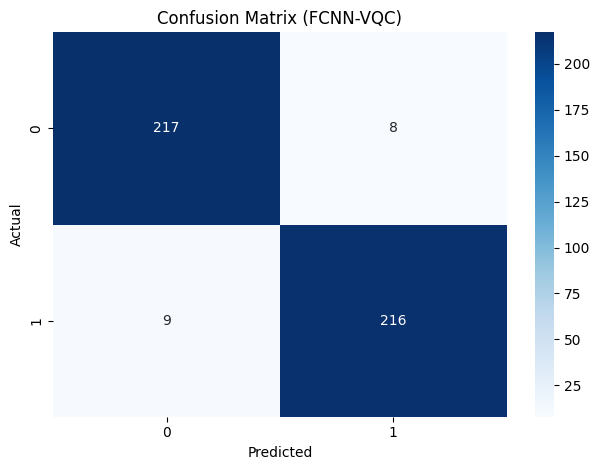

Saved - vqc_confusion_matrix.png


In [ ]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure()
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (FCNN-VQC)")
plt.tight_layout()
plt.savefig("vqc_confusion_matrix.png", dpi=150)
plt.show()
print("Saved - vqc_confusion_matrix.png")

AUC Score: 0.9827


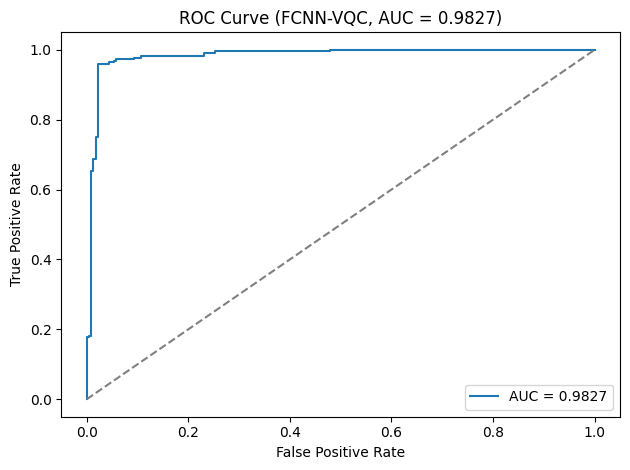

Saved - vqc_roc_curve.png


In [ ]:
fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)
print(f"AUC Score: {roc_auc:.4f}")
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], "--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve (FCNN-VQC, AUC = {roc_auc:.4f})")
plt.legend()
plt.tight_layout()
plt.savefig("vqc_roc_curve.png", dpi=150)
plt.show()
print("Saved - vqc_roc_curve.png")

Final Accuracy

In [ ]:
def get_accuracy(loader):
    model.eval()
    correct = 0
    total   = 0
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            outputs = model(xb)
            preds = (outputs > 0.5).float()
            correct += (preds.cpu() == yb).sum().item()
            total   += yb.size(0)
    return correct / total
train_acc = get_accuracy(train_loader)
val_acc   = get_accuracy(val_loader)
test_acc  = get_accuracy(test_loader)
print(f"Final VQC Train Accuracy:      {train_acc:.4f}")
print(f"Final VQC Validation Accuracy: {val_acc:.4f}")
print(f"Final VQC Test Accuracy:       {test_acc:.4f}")

Final VQC Train Accuracy:      0.9914
Final VQC Validation Accuracy: 0.9622
Final VQC Test Accuracy:       0.9622
